# Customer Fraud Detection - Binary Classification

**Goal:** Predict whether a customer record is fraudulent (`is_fraudulent` = 1) or not (0), using the available customer features.

**Pipeline:** Data -> Preprocessing -> Encoding -> Train/Test Split -> Scaling -> SMOTE (if required) -> Models (Decision Tree, Random Forest, XGBoost) -> Evaluation -> Model Comparison -> Best Model

## 1. Import Libraries

In [1]:
# Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('customer_analytics_dataset.csv')
df.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.6,2024-06-05,50,0.20
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.3,2024-02-19,37,0.34
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,NaN,2024-04-16,65,0.05
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.9,2020-07-08,93,0.19
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.3,2025-04-09,79,0.15


In [3]:
# Basic info - column names, data types, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5000 non-null   str    
 1   age                 5000 non-null   int64  
 2   gender              5000 non-null   str    
 3   country             5000 non-null   str    
 4   avg_order_value     4750 non-null   float64
 5   total_orders        5000 non-null   int64  
 6   last_purchase       5000 non-null   int64  
 7   is_fraudulent       5000 non-null   int64  
 8   preferred_category  5000 non-null   str    
 9   email_open_rate     4750 non-null   float64
 10  customer_since      5000 non-null   str    
 11  loyalty_score       5000 non-null   int64  
 12  churn_risk          5000 non-null   float64
dtypes: float64(3), int64(5), str(5)
memory usage: 507.9 KB


In [4]:
# Summary statistics for numeric columns
df.describe()

,age,avg_order_value,total_orders,last_purchase,is_fraudulent,email_open_rate,loyalty_score,churn_risk
count,5000.000000,4750.000000,5000.000000,5000.000000,5000.000000,4750.000000,5000.000000,5000.000000
mean,48.163200,108.442857,10.027000,180.073200,0.025800,50.714842,50.039400,0.284484
std,17.880797,69.265559,3.163838,104.926518,0.158554,29.098706,28.832151,0.159690
min,18.000000,10.660000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,33.000000,57.805000,8.000000,89.000000,0.000000,25.225000,25.000000,0.160000
50%,48.000000,93.190000,10.000000,178.000000,0.000000,50.950000,50.000000,0.260000
75%,64.000000,142.197500,12.000000,270.000000,0.000000,76.800000,75.000000,0.390000
max,79.000000,555.460000,23.000000,364.000000,1.000000,100.000000,99.000000,0.900000


## 3. EDA - Missing Values, Duplicates, Outliers, Target Distribution

In [5]:
# Check for missing values
df.isnull().sum()

customer_id             0
age                     0
gender                  0
country                 0
avg_order_value       250
total_orders            0
last_purchase           0
is_fraudulent           0
preferred_category      0
email_open_rate       250
customer_since          0
loyalty_score           0
churn_risk              0
dtype: int64

`avg_order_value` and `email_open_rate` have 250 missing values each. Both are numeric columns, so we fill them with the median.

In [6]:
# Fill missing values with median
df['avg_order_value'] = df['avg_order_value'].fillna(df['avg_order_value'].median())
df['email_open_rate'] = df['email_open_rate'].fillna(df['email_open_rate'].median())

df.isnull().sum()

customer_id           0
age                   0
gender                0
country               0
avg_order_value       0
total_orders          0
last_purchase         0
is_fraudulent         0
preferred_category    0
email_open_rate       0
customer_since        0
loyalty_score         0
churn_risk            0
dtype: int64

In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

### Outlier Check (numeric columns)

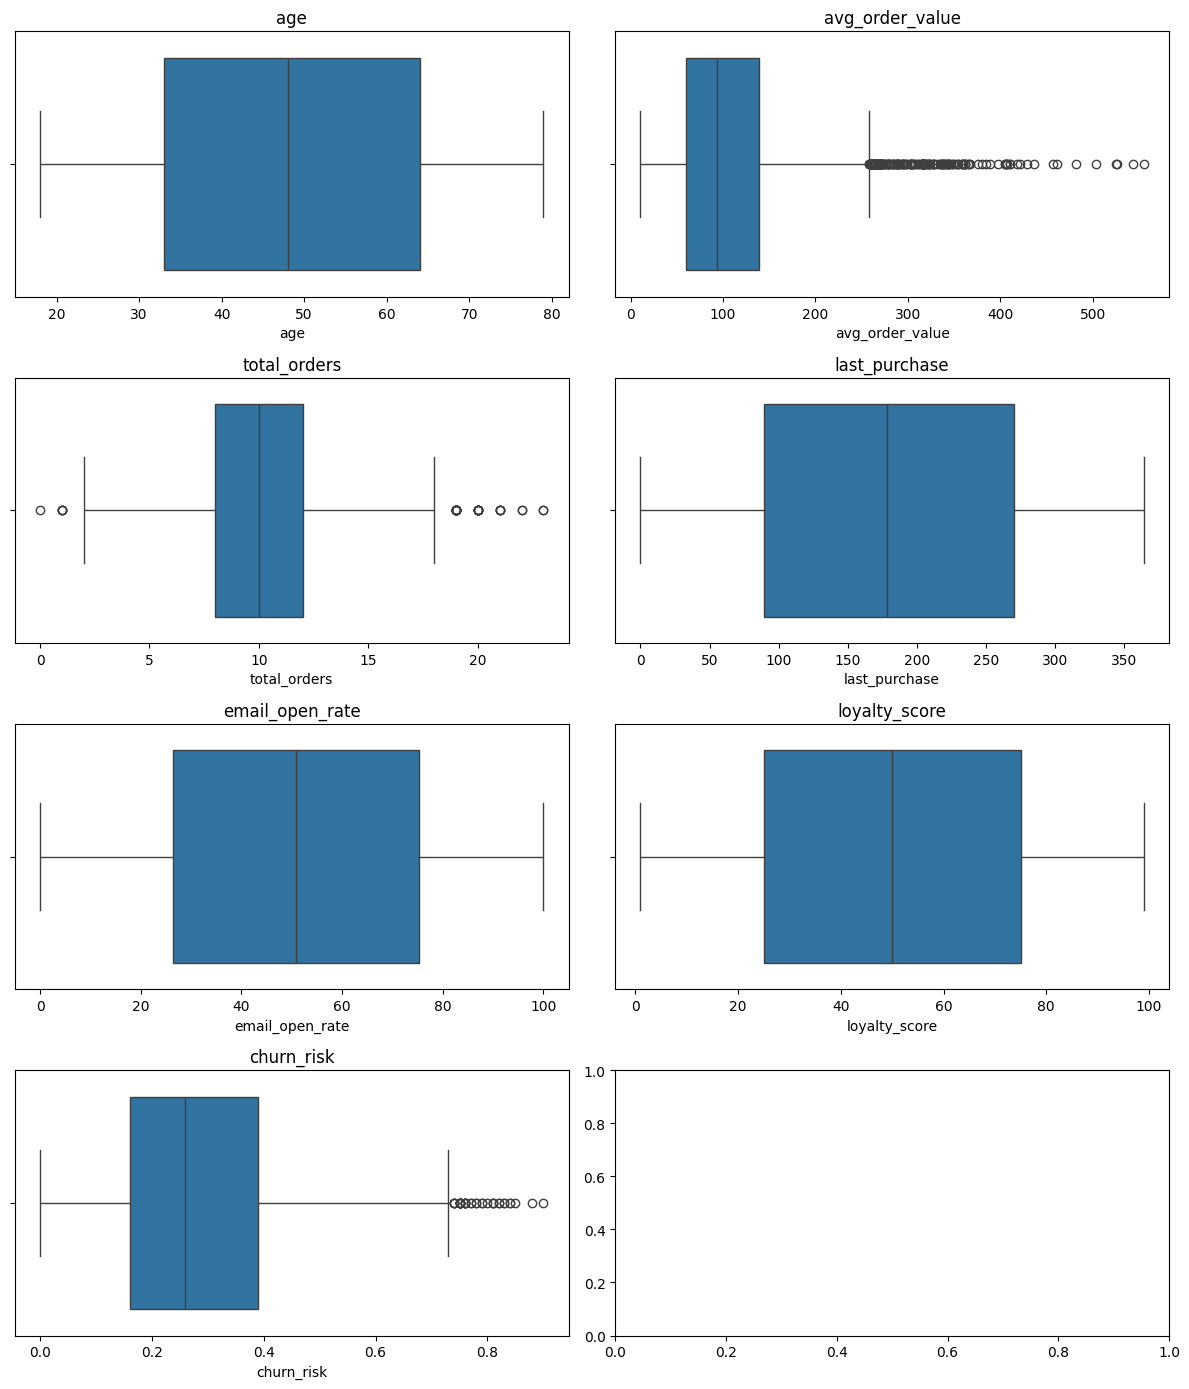

In [8]:
# Boxplots to visually check outliers in numeric columns
numeric_cols = ['age', 'avg_order_value', 'total_orders', 'last_purchase', 'email_open_rate', 'loyalty_score', 'churn_risk']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [9]:
# Check outliers using the IQR method for avg_order_value (the column most likely to have outliers)
Q1 = df['avg_order_value'].quantile(0.25)
Q3 = df['avg_order_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['avg_order_value'] < lower_bound) | (df['avg_order_value'] > upper_bound)]
print('Number of outliers in avg_order_value:', outliers.shape[0])
print('Lower bound:', lower_bound, 'Upper bound:', upper_bound)

Number of outliers in avg_order_value: 169
Lower bound: -59.31125 Upper bound: 257.67875000000004


The outliers in `avg_order_value` represent customers with genuinely high order values - this is realistic customer behaviour, not a data error, so these rows are kept rather than removed. Removing them could actually remove useful signal for fraud detection, since unusually high order values can sometimes be linked to fraudulent activity.

### Target Class Distribution

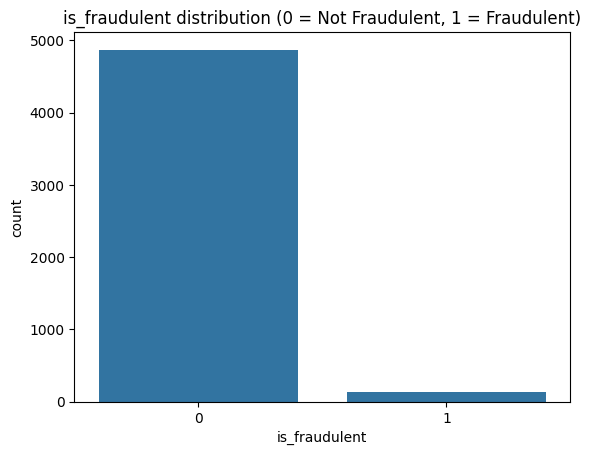

is_fraudulent
0    4871
1     129
Name: count, dtype: int64

In [10]:
sns.countplot(x='is_fraudulent', data=df)
plt.title('is_fraudulent distribution (0 = Not Fraudulent, 1 = Fraudulent)')
plt.show()

df['is_fraudulent'].value_counts()

In [11]:
# Percentage of each class
df['is_fraudulent'].value_counts(normalize=True) * 100

is_fraudulent
0    97.42
1     2.58
Name: proportion, dtype: float64

The target is heavily imbalanced - only about 2.6% of records are fraudulent.

### A Few More EDA Plots

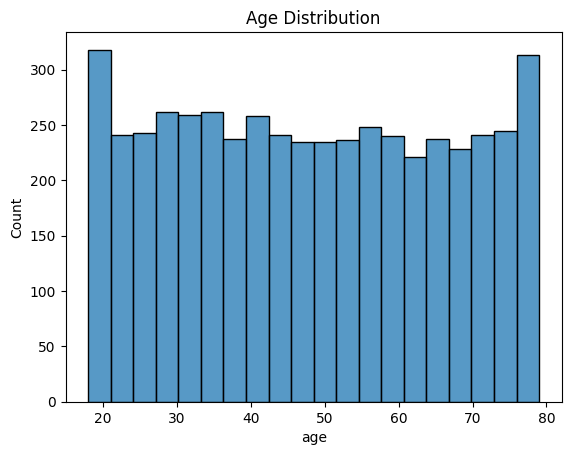

In [12]:
sns.histplot(df['age'], bins=20)
plt.title('Age Distribution')
plt.show()

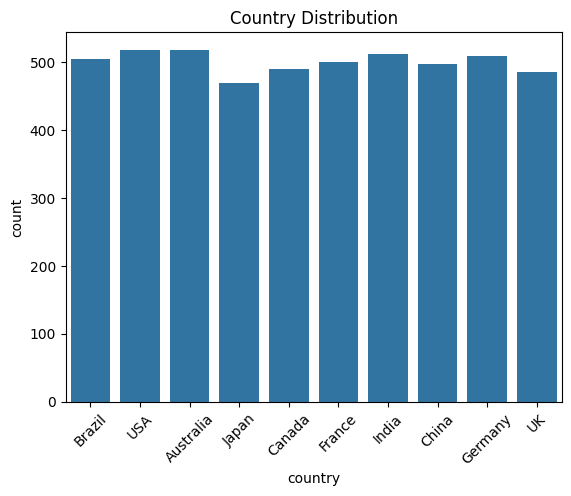

In [13]:
sns.countplot(x='country', data=df)
plt.xticks(rotation=45)
plt.title('Country Distribution')
plt.show()

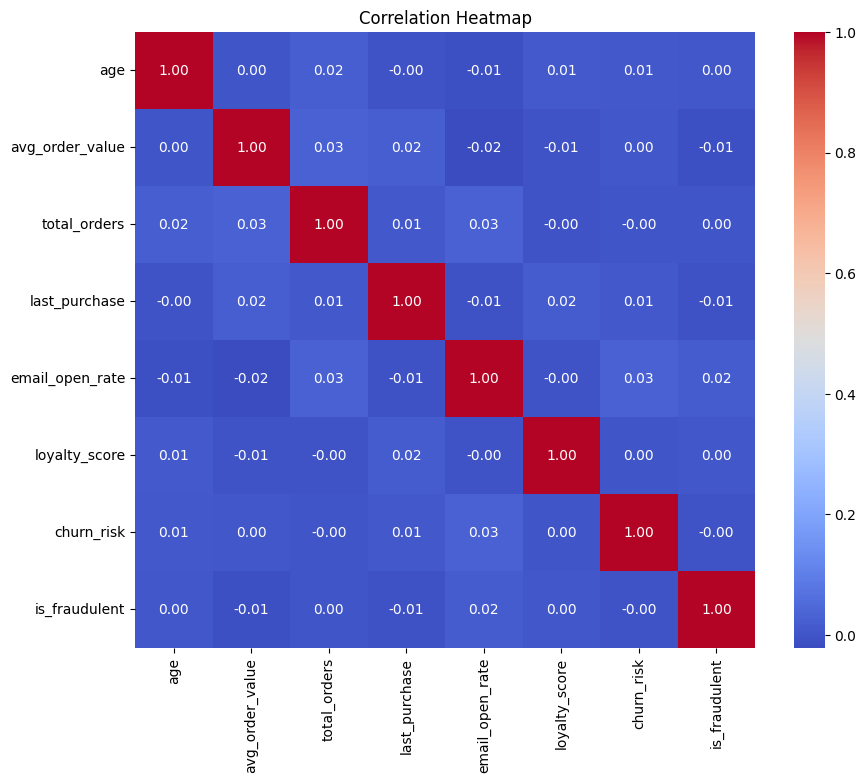

In [14]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols + ['is_fraudulent']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 4. Feature Engineering - customer_since

`customer_since` is a date column. A raw date is not useful for a model directly, so it is converted into a more useful numeric feature: the number of days since that date (i.e. how long the customer has been with us, counted from the most recent date in the dataset).

In [15]:
# Convert customer_since to datetime
df['customer_since'] = pd.to_datetime(df['customer_since'])

# Use the most recent date in the dataset as the reference point
reference_date = df['customer_since'].max()

# Create a new feature: number of days since the customer joined
df['customer_tenure_days'] = (reference_date - df['customer_since']).dt.days

df[['customer_since', 'customer_tenure_days']].head()

,customer_since,customer_tenure_days
0,2024-06-05,388
1,2024-02-19,495
2,2024-04-16,438
3,2020-07-08,1816
4,2025-04-09,80


In [16]:
# Drop the original date column since we now have a numeric version of it
df = df.drop(columns=['customer_since'])

## 5. Drop customer_id (identifier only, not a feature)

In [17]:
# customer_id is just an identifier, it has no predictive value, so we drop it
df = df.drop(columns=['customer_id'])
df.head()

,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_tenure_days
0,30,Female,Brazil,101.08,8,176,1,Beauty,25.60,50,0.20,388
1,53,Female,USA,90.39,10,88,0,Electronics,12.30,37,0.34,495
2,73,Male,Australia,83.28,6,203,0,Sports,50.95,65,0.05,438
3,30,Other,Japan,109.90,9,346,1,Electronics,42.90,93,0.19,1816
4,29,Female,Canada,269.38,16,342,0,Fashion,5.30,79,0.15,80


## 6. Encoding Categorical Columns

`gender`, `country`, and `preferred_category` are categorical (text) columns with no natural order between their categories, so **One-Hot Encoding** is used (not Label Encoding, which would wrongly imply an order between categories that do not actually have one).

In [18]:
# One-Hot Encode the categorical columns
categorical_cols = ['gender', 'country', 'preferred_category']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,age,avg_order_value,total_orders,last_purchase,is_fraudulent,email_open_rate,loyalty_score,churn_risk,customer_tenure_days,gender_Male,...,country_France,country_Germany,country_India,country_Japan,country_UK,country_USA,preferred_category_Electronics,preferred_category_Fashion,preferred_category_Home,preferred_category_Sports
0,30,101.08,8,176,1,25.60,50,0.20,388,False,...,False,False,False,False,False,False,False,False,False,False
1,53,90.39,10,88,0,12.30,37,0.34,495,False,...,False,False,False,False,False,True,True,False,False,False
2,73,83.28,6,203,0,50.95,65,0.05,438,True,...,False,False,False,False,False,False,False,False,False,True
3,30,109.90,9,346,1,42.90,93,0.19,1816,False,...,False,False,False,True,False,False,True,False,False,False
4,29,269.38,16,342,0,5.30,79,0.15,80,False,...,False,False,False,False,False,False,False,True,False,False


In [19]:
df_encoded.shape

(5000, 24)

## 7. Feature (X) and Target (y) Separation

In [20]:
# Target: what we are predicting
y = df_encoded['is_fraudulent']

# Features: everything else
X = df_encoded.drop(columns=['is_fraudulent'])

print(X.shape, y.shape)

(5000, 23) (5000,)


## 8. Train/Test Split

In [21]:
from sklearn.model_selection import train_test_split

# stratify=y keeps the same fraud/not-fraud ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((4000, 23), (1000, 23))

## 9. Feature Scaling

**StandardScaler** is used here instead of MinMaxScaler. StandardScaler scales features to have mean 0 and standard deviation 1, which works well when a dataset has outliers (like the ones seen in `avg_order_value`), since it does not squash all values into a fixed small range the way MinMaxScaler does. MinMaxScaler is more sensitive to outliers because a single extreme value changes the whole 0-1 scale for everyone else.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 10. Handling Imbalanced Target (SMOTE)

Since `is_fraudulent` is heavily imbalanced (about 97.4% vs 2.6%), SMOTE (Synthetic Minority Oversampling Technique) is applied. SMOTE creates synthetic examples of the minority class (fraud) so the model does not simply learn to always predict 'not fraud' and still get a high accuracy. SMOTE is applied only on the training data, never on the test data, so the model is evaluated on real, untouched data.

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', pd.Series(y_train_balanced).value_counts().to_dict())

Before SMOTE: {0: 3897, 1: 103}
After SMOTE: {0: 3897, 1: 3897}


## 11. Train Classification Models

### Decision Tree

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_balanced, y_train_balanced)
y_pred_dt = dt_model.predict(X_test_scaled)

print('Decision Tree Results')
print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Precision:', precision_score(y_test, y_pred_dt))
print('Recall:', recall_score(y_test, y_pred_dt))
print('F1-Score:', f1_score(y_test, y_pred_dt))
print()
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.945
Precision: 0.06060606060606061
Recall: 0.07692307692307693
F1-Score: 0.06779661016949153

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       974
           1       0.06      0.08      0.07        26

    accuracy                           0.94      1000
   macro avg       0.52      0.52      0.52      1000
weighted avg       0.95      0.94      0.95      1000



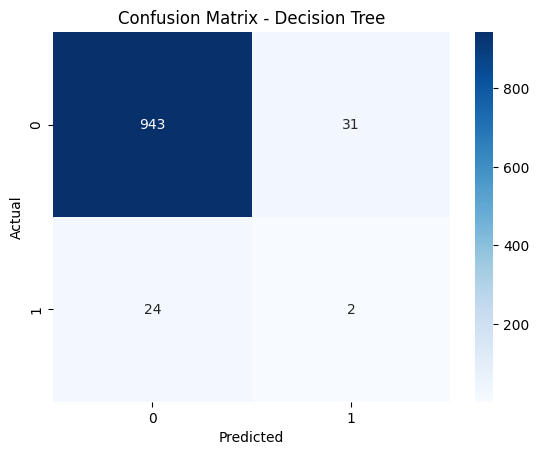

In [25]:
# Confusion Matrix - Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

### Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf_model.predict(X_test_scaled)

print('Random Forest Results')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Precision:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1-Score:', f1_score(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.969
Precision: 0.0
Recall: 0.0
F1-Score: 0.0

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       974
           1       0.00      0.00      0.00        26

    accuracy                           0.97      1000
   macro avg       0.49      0.50      0.49      1000
weighted avg       0.95      0.97      0.96      1000



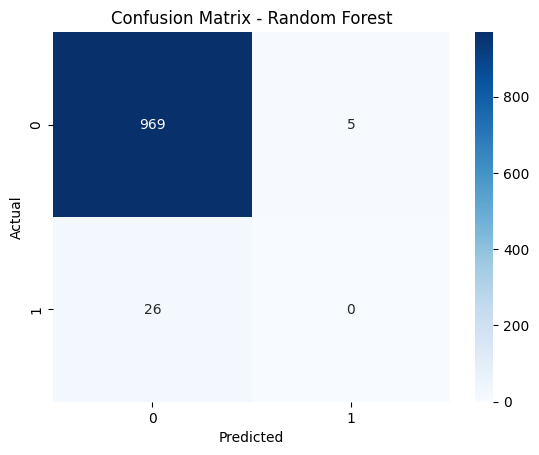

In [27]:
# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

### XGBoost

In [28]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_balanced, y_train_balanced)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print('XGBoost Results')
print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('F1-Score:', f1_score(y_test, y_pred_xgb))
print()
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy: 0.973
Precision: 0.0
Recall: 0.0
F1-Score: 0.0

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       974
           1       0.00      0.00      0.00        26

    accuracy                           0.97      1000
   macro avg       0.49      0.50      0.49      1000
weighted avg       0.95      0.97      0.96      1000



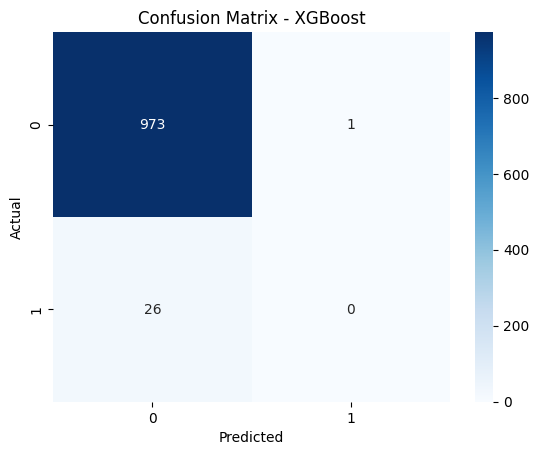

In [29]:
# Confusion Matrix - XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

### Logistic Regression (extra model for comparison)

In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_balanced, y_train_balanced)
y_pred_lr = lr_model.predict(X_test_scaled)

print('Logistic Regression Results')
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print('Precision:', precision_score(y_test, y_pred_lr))
print('Recall:', recall_score(y_test, y_pred_lr))
print('F1-Score:', f1_score(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.564
Precision: 0.0319634703196347
Recall: 0.5384615384615384
F1-Score: 0.0603448275862069


## 12. Compare All Models

In [31]:
# Put all models' results together in one table for easy comparison
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lr)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lr)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lr)
    ]
})

comparison = comparison.sort_values('F1-Score', ascending=False)
comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.945,0.060606,0.076923,0.067797
3,Logistic Regression,0.564,0.031963,0.538462,0.060345
1,Random Forest,0.969,0.000000,0.000000,0.000000
2,XGBoost,0.973,0.000000,0.000000,0.000000


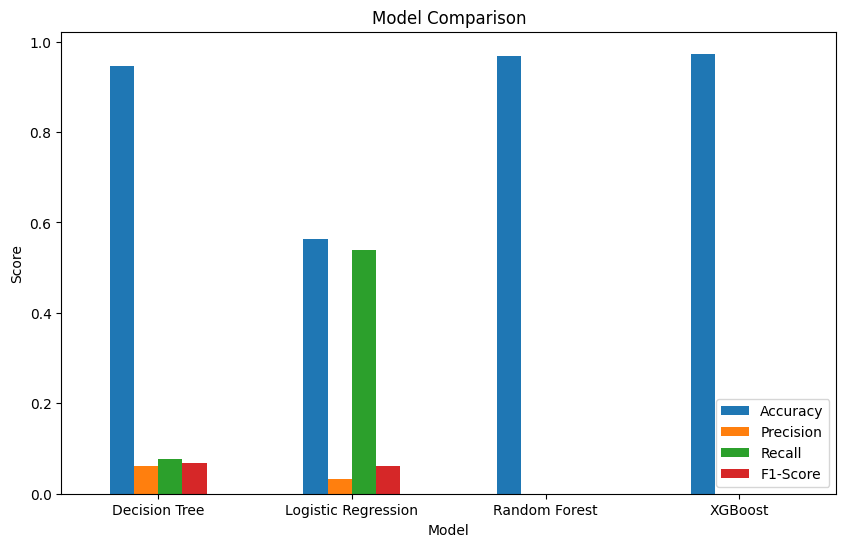

In [32]:
# Visualize the comparison
comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

## 13. Best Model and Final Prediction Results

Based on the comparison table above, the model with the highest F1-Score is selected as the best model. F1-Score is used to pick the best model (instead of just accuracy) because the dataset is imbalanced - a model could get high accuracy just by predicting 'not fraud' every time, without actually detecting any fraud. F1-Score balances precision and recall together, which matters more here.

In [33]:
# Show which model performed best
best_model_name = comparison.iloc[0]['Model']
print('Best performing model:', best_model_name)
comparison.iloc[0]

Best performing model: Decision Tree


Model        Decision Tree
Accuracy             0.945
Precision         0.060606
Recall            0.076923
F1-Score          0.067797
Name: 0, dtype: object

In [34]:
# Final prediction results table using the best model (Random Forest predictions shown as example)
final_results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred_rf})
final_results.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


## Summary

- **Encoding used:** One-Hot Encoding for `gender`, `country`, and `preferred_category`, since these are unordered categorical columns. One-Hot Encoding avoids implying a false ranking between categories.
- **Scaling used:** StandardScaler, chosen because it handles outliers (like in `avg_order_value`) better than MinMaxScaler, which is more sensitive to extreme values.
- **Balancing used:** SMOTE was applied because `is_fraudulent` was heavily imbalanced (about 97.4% vs 2.6%). SMOTE was applied only on the training data to avoid leaking information into the test set.
- **Model comparison:** Decision Tree, Random Forest, XGBoost, and Logistic Regression were all trained and compared using Accuracy, Precision, Recall, and F1-Score - see the comparison table and bar chart above for exact numbers.
- **Best model:** The model with the highest F1-Score was selected as the best performer, since F1-Score balances precision and recall, which matters most for an imbalanced fraud detection problem.